In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
HR_Attrition = pd.read_csv('HR_Attrition.csv')
HR_Attrition

,Satisfaction_Level,Last_Evaluation,Number_of_Projects,Average_Monthly_Hours,Time_Spent_in_Company,Work_Accident,Left,Promotion_in_Last_5_Years,Department,Salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
11986,0.90,0.55,3,259,10,1,0,1,management,high
11987,0.74,0.95,5,266,10,0,0,1,management,high
11988,0.85,0.54,3,185,10,0,0,1,management,high
11989,0.33,0.65,3,172,10,0,0,1,marketing,high


/tmp/ipykernel_151/1249485269.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=HR_Attrition, x='Left', palette=['#2196F3','#F44336'])


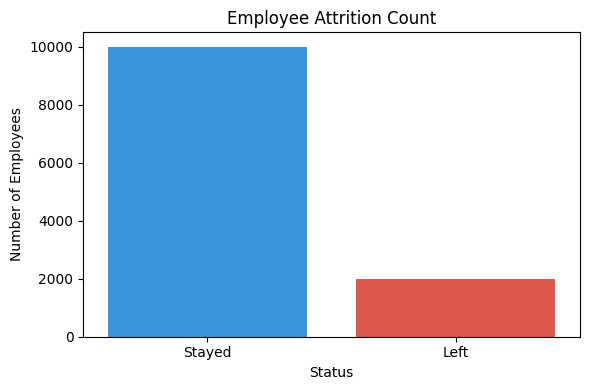

In [ ]:
# Attrition Count

plt.figure(figsize=(6,4))
sns.countplot(data=HR_Attrition, x='Left', palette=['#2196F3','#F44336'])
plt.xticks([0,1], ['Stayed', 'Left'])
plt.title('Employee Attrition Count')
plt.xlabel('Status')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('chart1_attrition_count.png')
plt.show()


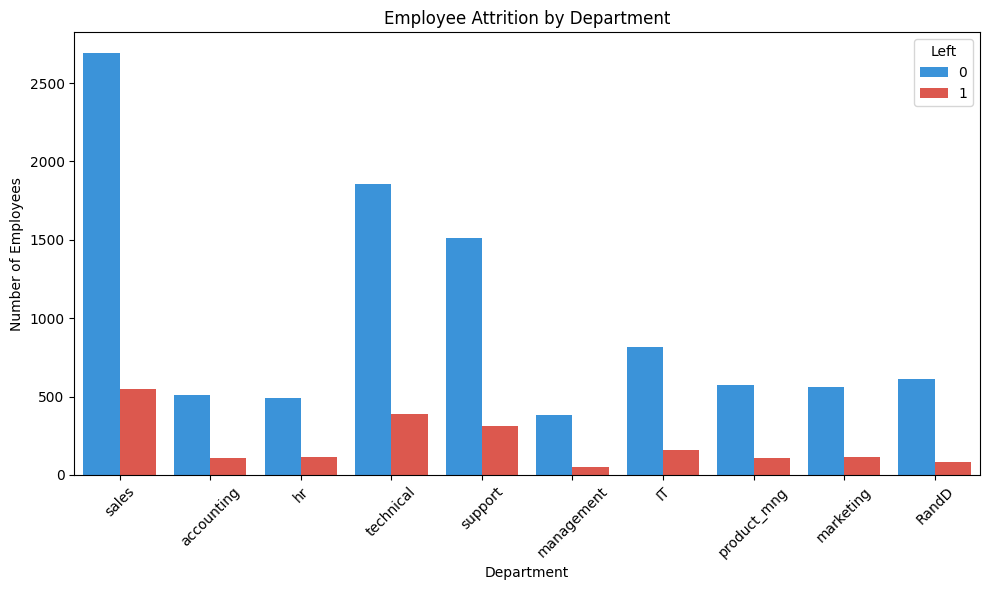

In [ ]:
# Attrition by Department

plt.figure(figsize=(10,6))
sns.countplot(data=HR_Attrition, x='Department', hue='Left', palette=['#2196F3','#F44336'])
plt.xticks(rotation=45)
plt.title('Employee Attrition by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('chart2_attrition_by_department.png')
plt.show()

/tmp/ipykernel_151/4105781630.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=salary, x='Salary', y='Attrition_Rate', palette='Oranges_r')


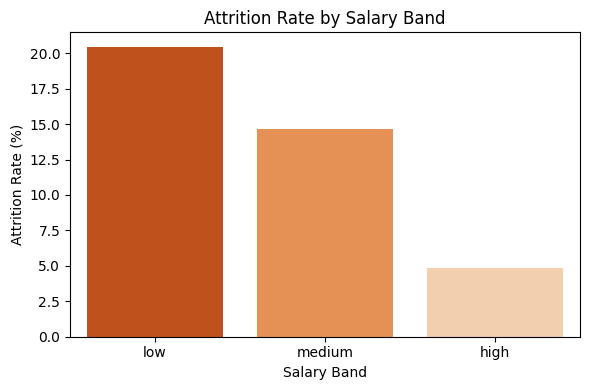

In [ ]:
# Attrition by Sales Band
salary_order = ['low', 'medium', 'high']
salary = HR_Attrition.groupby('Salary')['Left'].mean().mul(100).round(2).reindex(salary_order).reset_index()
salary.columns = ['Salary', 'Attrition_Rate']

plt.figure(figsize=(6,4))
sns.barplot(data=salary, x='Salary', y='Attrition_Rate', palette='Oranges_r')
plt.title('Attrition Rate by Salary Band')
plt.xlabel('Salary Band')
plt.ylabel('Attrition Rate (%)')
plt.tight_layout()
plt.savefig('chart3_attrition_by_salary.png')
plt.show()


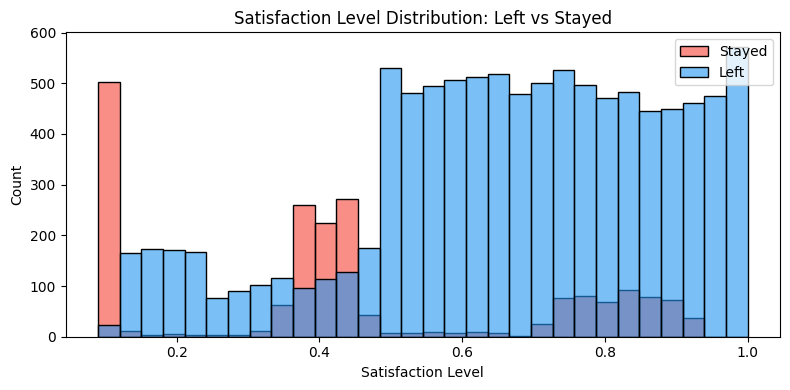

In [ ]:
# Satisfaction Distribution
plt.figure(figsize=(8,4))
sns.histplot(data=HR_Attrition, x='Satisfaction_Level', hue='Left', bins=30,
             palette={0:'#2196F3', 1:'#F44336'}, alpha=0.6)
plt.title('Satisfaction Level Distribution: Left vs Stayed')
plt.xlabel('Satisfaction Level')
plt.ylabel('Count')
plt.legend(labels=['Stayed', 'Left'])
plt.tight_layout()
plt.savefig('chart4_satisfaction_distribution.png')
plt.show()


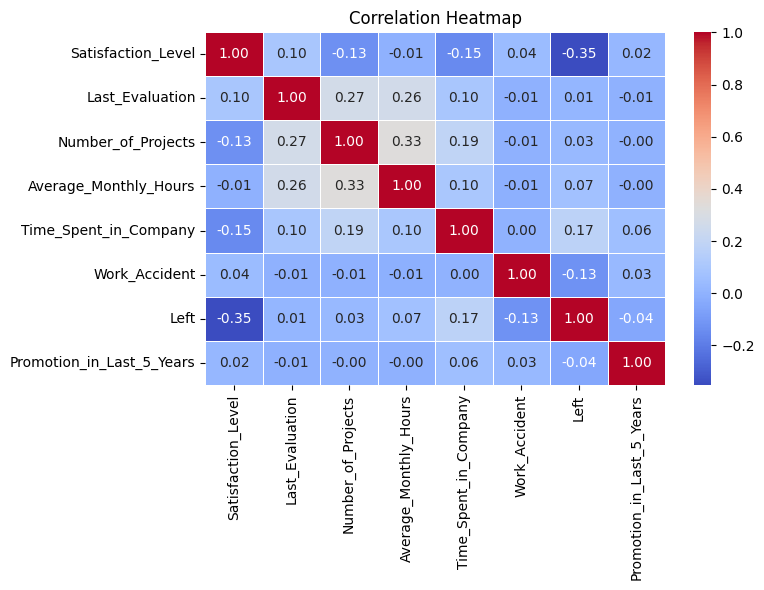

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
corr = HR_Attrition.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('chart5_correlation_heatmap.png')
plt.show()
